## RQ 3 Observation 3.1

In [1]:
# === RQ3 Stats — Crystal-Clear Totals That Add Up ===
# Prints ONLY:
# 1) Total change episodes (≥0 duration): N across M repos
# 2) Total change styles (per-style stints, ≥0 duration): S across R repos
# 3) Excluded by ≥14-day rule (per-style, removed-only): K styles across Q repos
# 4) Duration stats + style distributions for EXCLUDED and NOT EXCLUDED
#
# Definitions:
# - Episodes: ALL dated rows -> contiguous [start,end) spans (styles may be empty). Zero-length allowed.
# - Per-style stints: merged add→remove intervals per style, capped at cutoff. Zero-length allowed.
# - Excluded = stints that ENDED BEFORE cutoff AND duration < 14 days (removed-only rule).
# - Not Excluded = ALL OTHER stints (ended ≥14d OR active at cutoff). Ensures: Excluded + NotExcluded == Total styles.

from __future__ import annotations
from pathlib import Path
from datetime import datetime, timezone
from typing import Dict, List, Optional, Tuple
import json
import pandas as pd

# ---------- Paths (edit if needed) ----------
WORK_ROOT_MINED = Path(r"C:\Android Mobile App\Step2_Clone_Repo\Type_1\Aug_10\RQ3")
OUTPUT_MINE = WORK_ROOT_MINED / "mineV9.3"   # V9.3 miner outputs

# ---------- Settings ----------
CUTOFF_ISO  = "2025-08-10 23:59:59 +0000"
PERSIST_MIN = 14.0
STYLES      = ("Emu_Community", "Emu_Custom", "GMD", "ThirdParty")

# ---------- Helpers ----------
def parse_iso(s: Optional[str]) -> Optional[datetime]:
    if not s:
        return None
    s = s.strip()
    if s.endswith("Z"):
        s = s[:-1] + "+00:00"
    if len(s) >= 5 and (s[-5] in ["+","-"]) and s[-3] != ":":
        s = s[:-2] + ":" + s[-2:]
    try:
        dt = datetime.fromisoformat(s)
        if dt.tzinfo is None:
            dt = dt.replace(tzinfo=timezone.utc)
        return dt.astimezone(timezone.utc)
    except Exception:
        return None

CUTOFF_DT = parse_iso(CUTOFF_ISO)
assert CUTOFF_DT is not None, "Bad CUTOFF_ISO"

def days_between(a: datetime, b: datetime) -> float:
    return (b - a).total_seconds() / 86400.0

def read_repo_jsons(out_dir: Path) -> List[Path]:
    return sorted([p for p in out_dir.glob("*.emulator_timeline.json") if p.name != "index_summary.json"])

def build_episodes(timeline_rows: List[Dict], cutoff_dt: datetime) -> List[Dict]:
    """
    Contiguous episodes from ALL dated rows (styles may be empty).
    Keep spans with duration >= 0 (zero-length allowed). Cap at cutoff.
    """
    rows = sorted(
        (r for r in (timeline_rows or []) if r.get("date") is not None),
        key=lambda r: parse_iso(r.get("date")) or datetime.min.replace(tzinfo=timezone.utc)
    )
    eps: List[Dict] = []
    for i, r in enumerate(rows):
        start = parse_iso(r.get("date"))
        if start is None:
            continue
        styles_raw = set(r.get("styles") or [])  # may be empty
        next_dt = parse_iso(rows[i+1].get("date")) if (i + 1) < len(rows) else cutoff_dt
        end = min(next_dt or cutoff_dt, cutoff_dt)
        if end < start:  # discard only negative spans
            continue
        eps.append({
            "start": start,
            "end": end,
            "styles": styles_raw,
            "duration_days": max(0.0, days_between(start, end)),
        })
    return eps

def merge_intervals(intervals: List[Tuple[datetime, datetime]]) -> List[Tuple[datetime, datetime]]:
    """Merge overlapping/contiguous [start,end) intervals."""
    if not intervals:
        return []
    intervals.sort(key=lambda ab: ab[0])
    merged: List[Tuple[datetime, datetime]] = []
    cs, ce = intervals[0]
    for a, b in intervals[1:]:
        if a <= ce:
            if b > ce:
                ce = b
        else:
            merged.append((cs, ce))
            cs, ce = a, b
    merged.append((cs, ce))
    return merged

def per_style_intervals(episodes: List[Dict]) -> Dict[str, List[Tuple[datetime, datetime]]]:
    """
    For each canonical style, collect and merge episode sub-intervals where that style is present.
    Produces per-style add→remove stints (capped at cutoff).
    """
    m = {s: [] for s in STYLES}
    for ep in episodes:
        present = ep["styles"] or set()
        for s in STYLES:
            if s in present:
                m[s].append((ep["start"], ep["end"]))
    return {s: merge_intervals(v) for s, v in m.items() if v}

# ---------- Load & compute ----------
json_files = read_repo_jsons(OUTPUT_MINE)
if not json_files:
    raise FileNotFoundError(f"No miner JSONs found in {OUTPUT_MINE}")

episode_rows, stint_rows = [], []

for jf in json_files:
    with jf.open("r", encoding="utf-8") as f:
        data = json.load(f)
    repo = data.get("repo_name") or jf.stem

    episodes = build_episodes(data.get("timeline") or [], CUTOFF_DT)

    # 1) Episodes (ALL; >=0 duration)
    for ep in episodes:
        episode_rows.append({
            "repo_name": repo,
            "start": ep["start"],
            "end": ep["end"],
            "duration_days": ep["duration_days"],
        })

    # 2) Per-style stints (merged intervals per style)
    psi = per_style_intervals(episodes)
    for style, ivs in psi.items():
        for a, b in ivs:
            stint_rows.append({
                "repo_name": repo,
                "style": style,
                "start": a,
                "end": b,  # capped at cutoff
                "duration_days": max(0.0, days_between(a, b)),
                "ended_before_cutoff": 1 if b < CUTOFF_DT else 0,
            })

episodes_df = pd.DataFrame(episode_rows).sort_values(["start","repo_name"]).reset_index(drop=True)
stints_df   = pd.DataFrame(stint_rows).sort_values(["start","repo_name","style"]).reset_index(drop=True)

if episodes_df.empty:
    print("No data. Check miner outputs.")
else:
    # (1) Total change episodes ≥0 duration
    total_eps = len(episodes_df)
    repos_with_eps = episodes_df["repo_name"].nunique()
    print(f"Total number of change episodes >= 0 (all kinds): {total_eps} across {repos_with_eps} repos")

    # (2) Total change styles ≥0 duration (per-style stints)
    total_styles = len(stints_df)
    repos_with_styles = stints_df["repo_name"].nunique()
    print(f"Total number of change styles >= 0 (all kinds): {total_styles} across {repos_with_styles} repos")

    # Split into EXCLUDED (removed-only <14d) vs NOT EXCLUDED (everything else)
    excluded = stints_df[(stints_df["ended_before_cutoff"] == 1) &
                         (stints_df["duration_days"] < PERSIST_MIN)].copy()
    not_excluded = stints_df.drop(index=excluded.index).copy()  # complement

    # (3) Excluded summary
    excl_repos = excluded["repo_name"].nunique()
    print(f"Total number of excluded styles by 14-day rule: {len(excluded)} styles across {excl_repos} repos")

    # Sanity check: sums must match total styles
    assert len(excluded) + len(not_excluded) == total_styles, "Excluded + NotExcluded must equal Total styles"
    # (Optional) print the check
    print(f"[check] Excluded + Not Excluded = {len(excluded) + len(not_excluded)} (matches total styles: {total_styles})")

    # (4) Duration stats + style distributions
    def dstats(df: pd.DataFrame, title: str):
        print(f"\nDuration stats — {title} (days):")
        if df.empty:
            print("  (none)")
        else:
            print(df["duration_days"].describe().round(2))

    def style_dist(df: pd.DataFrame, title: str):
        print(f"\nStyle distribution — {title}:")
        if df.empty:
            for s in STYLES:
                print(f"{s}\t0")
        else:
            counts = df["style"].value_counts().reindex(STYLES, fill_value=0)
            # Optional: also show share
            shares = (counts / max(1, counts.sum())).round(3)
            out = pd.DataFrame({"count": counts, "share": shares})
            print(out)

    dstats(excluded, "EXCLUDED (<14d; ended before cutoff)")
    dstats(not_excluded, "NOT EXCLUDED (ended ≥14d OR active at cutoff)")

    style_dist(excluded, "EXCLUDED (<14d; ended before cutoff)")
    style_dist(not_excluded, "NOT EXCLUDED (ended ≥14d OR active at cutoff)")


Total number of change episodes >= 0 (all kinds): 529 across 350 repos
Total number of change styles >= 0 (all kinds): 506 across 350 repos
Total number of excluded styles by 14-day rule: 50 styles across 24 repos
[check] Excluded + Not Excluded = 506 (matches total styles: 506)

Duration stats — EXCLUDED (<14d; ended before cutoff) (days):
count    50.00
mean      2.39
std       3.90
min       0.00
25%       0.03
50%       0.52
75%       2.83
max      13.95
Name: duration_days, dtype: float64

Duration stats — NOT EXCLUDED (ended ≥14d OR active at cutoff) (days):
count     456.00
mean     1580.61
std      1090.57
min        15.96
25%       659.46
50%      1474.40
75%      2065.53
max      4243.05
Name: duration_days, dtype: float64

Style distribution — EXCLUDED (<14d; ended before cutoff):
               count  share
style                      
Emu_Community     21   0.42
Emu_Custom        22   0.44
GMD                3   0.06
ThirdParty         4   0.08

Style distribution — NOT EXC

## RQ3 - F1 

=== RQ3 — First vs Current (Repo-wide) — Bucketed Distributions ===
Loaded: C:\Android Mobile App\Step3_Instr_Testing_Analysis\Type_1\Aug_10\RQ3\Observations\obs3_1_entry_vs_current.csv
Total repositories used (both first & current defined): 349

  Category  First_count  First_rate_%  Current_count  Current_rate_%
 Community          161          46.1            179            51.3
    Custom          167          47.9            102            29.2
       GMD           10           2.9             11             3.2
ThirdParty           11           3.2             10             2.9
     Mixed            0           0.0             47            13.5


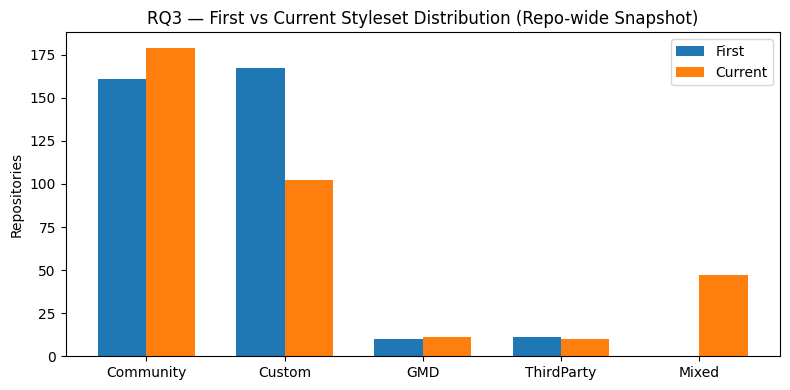

In [2]:
# First vs Current (Repo-wide) distribution with buckets: Community, Custom, GMD, ThirdParty, Mixed
# - FIRST  = per-style union ≥14d (prefer first_styleset_union14d, else first_styleset, else first_label)
# - CURRENT= repo-wide snapshot at cutoff (prefer current_styleset_snapshot, else current_label_snapshot)
# - Buckets: Community, Custom, GMD, ThirdParty, Mixed (Mixed = ANY combo with size >= 2; 'Both' is folded into Mixed)
# - Prints one table (counts + rates) and a bar chart. No files written.

import os, glob, pandas as pd, numpy as np, matplotlib.pyplot as plt
from typing import Set

# ---------- Locate CSV ----------
candidates = [
    r"C:\Android Mobile App\Step3_Instr_Testing_Analysis\Type_1\Aug_10\RQ3\Observations\obs3_1_entry_vs_current.csv",
    "/mnt/data/obs3_1_entry_vs_current.csv",
]
csv_path = next((p for p in candidates if os.path.exists(p)), None)
if csv_path is None:
    hits = glob.glob("/mnt/data/**/*.csv", recursive=True)
    for h in hits:
        if os.path.basename(h).lower() == "obs3_1_entry_vs_current.csv":
            csv_path = h
            break
if csv_path is None or not os.path.exists(csv_path):
    raise FileNotFoundError("Could not find obs3_1_entry_vs_current.csv. Please verify the path.")

df = pd.read_csv(csv_path, dtype=str, keep_default_na=False, encoding="utf-8")

# ---------- Helpers ----------
CANON = {"Emu_Community", "Emu_Custom", "GMD", "ThirdParty"}
MAP_HUMAN = {
    "Emu_Community": "Community",
    "Emu_Custom": "Custom",
    "GMD": "GMD",
    "ThirdParty": "ThirdParty",
}
ORDER = ["Community", "Custom", "GMD", "ThirdParty", "Mixed"]  # no 'Both'

def parse_styleset(styleset_str: str) -> Set[str]:
    if not styleset_str:
        return set()
    parts = [p.strip() for p in styleset_str.split("+") if p.strip()]
    return {p for p in parts if p in CANON}

def to_bucket(styleset_str: str) -> str:
    """
    Map a styleset string to one of: Community, Custom, GMD, ThirdParty, Mixed, or None.
    Mixed = ANY combination with size >= 2 (including the old 'Both').
    """
    sset = parse_styleset(styleset_str)
    if not sset:
        return "None"
    if len(sset) == 1:
        return MAP_HUMAN[next(iter(sset))]
    return "Mixed"  # includes the former 'Both'

def get_first_bucket(row) -> str:
    # Prefer the explicit union≥14d column; then the older styleset; finally the label.
    for key in ["first_styleset_union14d", "first_styleset"]:
        if key in row and str(row[key]).strip():
            return to_bucket(str(row[key]).strip())
    lbl = str(row.get("first_label", "")).strip()
    # Fold any legacy 'Both' label into Mixed
    if lbl == "Both":
        return "Mixed"
    if lbl in {"Community", "Custom", "GMD", "ThirdParty"}:
        return lbl
    return "None"

def get_current_bucket(row) -> str:
    if "current_styleset_snapshot" in row and str(row["current_styleset_snapshot"]).strip():
        return to_bucket(str(row["current_styleset_snapshot"]).strip())
    lbl = str(row.get("current_label_snapshot", "")).strip()
    # Fold any legacy 'Both' label into Mixed
    if lbl == "Both":
        return "Mixed"
    if lbl in {"Community", "Custom", "GMD", "ThirdParty"}:
        return lbl
    return "None"

# ---------- Compute ----------
df["_first_bucket"] = df.apply(get_first_bucket, axis=1)
df["_current_bucket"] = df.apply(get_current_bucket, axis=1)

df_plot = df[(df["_first_bucket"] != "None") & (df["_current_bucket"] != "None")].copy()

first_counts = df_plot["_first_bucket"].value_counts().reindex(ORDER, fill_value=0)
current_counts = df_plot["_current_bucket"].value_counts().reindex(ORDER, fill_value=0)

n = len(df_plot)
first_rates = (first_counts / n * 100).round(1)
current_rates = (current_counts / n * 100).round(1)

# Sanity checks
assert first_counts.sum() == n, "First counts must sum to total repos used."
assert current_counts.sum() == n, "Current counts must sum to total repos used."

table = pd.DataFrame({
    "Category": ORDER,
    "First_count": first_counts.values,
    "First_rate_%": first_rates.values,
    "Current_count": current_counts.values,
    "Current_rate_%": current_rates.values,
})

print("=== RQ3 — First vs Current (Repo-wide) — Bucketed Distributions ===")
print(f"Loaded: {csv_path}")
print(f"Total repositories used (both first & current defined): {n}\n")
print(table.to_string(index=False))

# ---------- Chart ----------
x = np.arange(len(ORDER))
width = 0.35
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(x - width/2, first_counts.values, width, label="First")
ax.bar(x + width/2, current_counts.values, width, label="Current")
ax.set_xticks(x)
ax.set_xticklabels(ORDER, rotation=0, ha="center")
ax.set_ylabel("Repositories")
ax.set_title("RQ3 — First vs Current Styleset Distribution (Repo-wide Snapshot)")
ax.legend()
plt.tight_layout()
plt.show()


## RQ3 - F2

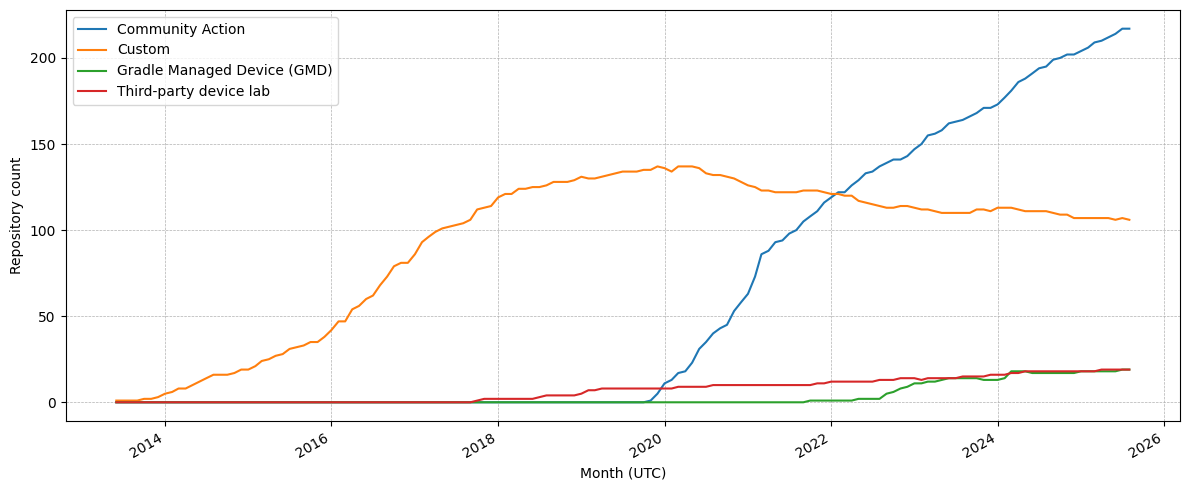

In [3]:
# === Observation 3.2 — Monthly Trends (single plot, no files) ===
# - Reads miner V9.3 JSONs (*.emulator_timeline.json)
# - 14-day rule is applied PER-STYLE (removed-only):
#     keep intervals if duration >= 14d OR the interval ends at the cutoff (active at cutoff)
# - Monthly counts: repo counts per style per month (multi-style months credit each style)
# - Single matplotlib chart; no saving to disk

from __future__ import annotations
from pathlib import Path
from datetime import datetime, timezone, timedelta
from typing import Dict, List, Optional, Set, Tuple
import json
import pandas as pd
import matplotlib.pyplot as plt  # matplotlib only

# -------- Paths --------
WORK_ROOT_MINED = Path(r"C:\Android Mobile App\Step2_Clone_Repo\Type_1\Aug_10\RQ3")
OUTPUT_MINE = WORK_ROOT_MINED / "mineV9.3"  # folder with *.emulator_timeline.json

# -------- Settings --------
CUTOFF_ISO   = "2025-08-10 23:59:59 +0000"    # must match miner
PERSIST_DAYS = 14.0
STYLES       = ("Emu_Community", "Emu_Custom", "GMD", "ThirdParty")

# Human-friendly labels for the plot
LABELS = {
    "Emu_Community": "Community Action",
    "Emu_Custom":    "Custom",
    "GMD":           "Gradle Managed Device (GMD)",
    "ThirdParty":    "Third-party device lab",
}

# -------- Helpers --------
def parse_iso(s: Optional[str]) -> Optional[datetime]:
    if not s:
        return None
    s = s.strip()
    if s.endswith("Z"):
        s = s[:-1] + "+00:00"
    if len(s) >= 5 and (s[-5] in ["+", "-"]) and s[-3] != ":":
        s = s[:-2] + ":" + s[-2:]
    try:
        dt = datetime.fromisoformat(s)
        if dt.tzinfo is None:
            dt = dt.replace(tzinfo=timezone.utc)
        return dt.astimezone(timezone.utc)
    except Exception:
        return None

CUTOFF_DT = parse_iso(CUTOFF_ISO)
assert CUTOFF_DT is not None, "Bad CUTOFF_ISO"

def days_between(a: datetime, b: datetime) -> float:
    return (b - a).total_seconds() / 86400.0

def read_repo_jsons(output_dir: Path) -> List[Path]:
    return sorted([p for p in output_dir.glob("*.emulator_timeline.json") if p.name != "index_summary.json"])

# ---- TZ-safe month helpers ----
def month_start_key(dt: datetime) -> pd.Timestamp:
    """Return a naive pd.Timestamp at the UTC month start for dt."""
    dt_utc = dt.astimezone(timezone.utc)
    return pd.Timestamp(year=dt_utc.year, month=dt_utc.month, day=1)

def next_month(ts: pd.Timestamp) -> pd.Timestamp:
    y, m = ts.year, ts.month
    return pd.Timestamp(year=y + (1 if m == 12 else 0), month=(1 if m == 12 else m + 1), day=1)

def month_range_covering(a: datetime, b: datetime) -> List[pd.Timestamp]:
    """
    Months covering [a,b). Includes the month of 'a' and any month that 'b' spills into.
    """
    if b <= a:
        return []
    months: List[pd.Timestamp] = []
    cur = month_start_key(a)
    last = month_start_key(b - timedelta(microseconds=1))
    while cur <= last:
        months.append(cur)
        cur = next_month(cur)
    return months

# -------- Build episodes from miner timeline --------
def build_episodes(timeline_rows: List[Dict], cutoff_dt: datetime) -> List[Dict]:
    rows = sorted(
        (r for r in (timeline_rows or []) if r.get("styles")),
        key=lambda r: parse_iso(r.get("date")) or datetime.min.replace(tzinfo=timezone.utc)
    )
    eps: List[Dict] = []
    for i, r in enumerate(rows):
        start = parse_iso(r.get("date"))
        if start is None:
            continue
        styles_set = set(r.get("styles") or [])
        nxt_date = parse_iso(rows[i+1].get("date")) if (i + 1) < len(rows) else cutoff_dt
        end = min(nxt_date or cutoff_dt, cutoff_dt)
        if end <= start:
            continue
        eps.append({
            "start": start,
            "end": end,
            "styles": styles_set,
        })
    return eps

# -------- Per-style interval utilities (union across episodes) --------
def merge_intervals(intervals: List[Tuple[datetime, datetime]]) -> List[Tuple[datetime, datetime]]:
    if not intervals:
        return []
    intervals.sort(key=lambda ab: ab[0])
    merged: List[Tuple[datetime, datetime]] = []
    s, e = intervals[0]
    for a, b in intervals[1:]:
        if a <= e:  # overlap or contiguous
            if b > e:
                e = b
        else:
            merged.append((s, e))
            s, e = a, b
    merged.append((s, e))
    return merged

def per_style_intervals(episodes: List[Dict]) -> Dict[str, List[Tuple[datetime, datetime]]]:
    m: Dict[str, List[Tuple[datetime, datetime]]] = {s: [] for s in STYLES}
    for ep in episodes:
        for s in STYLES:
            if s in ep["styles"]:
                m[s].append((ep["start"], ep["end"]))
    return {s: merge_intervals(v) for s, v in m.items() if v}

def apply_removed_only_rule(psi: Dict[str, List[Tuple[datetime, datetime]]],
                            cutoff_dt: datetime,
                            min_days: float) -> Dict[str, List[Tuple[datetime, datetime]]]:
    """
    Keep interval if:
      - duration >= min_days, OR
      - interval ends at cutoff_dt (active at cutoff) regardless of duration.
    """
    kept: Dict[str, List[Tuple[datetime, datetime]]] = {}
    for s, ivs in psi.items():
        out: List[Tuple[datetime, datetime]] = []
        for a, b in ivs:
            if days_between(a, b) >= min_days or b == cutoff_dt:
                out.append((a, b))
        if out:
            kept[s] = out
    return kept

# -------- Load miner outputs and build kept per-style intervals per repo --------
json_files = read_repo_jsons(OUTPUT_MINE)
if not json_files:
    raise FileNotFoundError(f"No miner JSON files found under: {OUTPUT_MINE}")

repo_style_intervals: Dict[str, Dict[str, List[Tuple[datetime, datetime]]]] = {}

for jf in json_files:
    with jf.open("r", encoding="utf-8") as f:
        data = json.load(f)
    repo = data.get("repo_name") or jf.stem

    episodes = build_episodes(data.get("timeline") or [], CUTOFF_DT)
    psi = per_style_intervals(episodes)
    kept = apply_removed_only_rule(psi, CUTOFF_DT, PERSIST_DAYS)  # per-style filter
    repo_style_intervals[repo] = kept

# -------- Build monthly counts per style --------
rows_monthly: List[Dict] = []

for repo, style_map in repo_style_intervals.items():
    # Determine months to consider for this repo: union over kept intervals
    intervals_all = [iv for ivs in style_map.values() for iv in ivs]
    if not intervals_all:
        continue
    start_min = min(s for s, _ in intervals_all)
    end_max   = max(e for _, e in intervals_all)
    months = month_range_covering(start_min, end_max)

    for m in months:
        # month window in UTC
        m_start = m.tz_localize("UTC")
        m_end   = next_month(m).tz_localize("UTC")

        # For each style, check if any kept interval overlaps [m_start, m_end)
        row = {"repo_name": repo, "month": m}
        for s in STYLES:
            active = 0
            for a, b in style_map.get(s, []):
                if a < m_end and b > m_start:  # overlap
                    active = 1
                    break
            row[s] = active
        rows_monthly.append(row)

dfm = pd.DataFrame(rows_monthly)
if dfm.empty:
    raise RuntimeError("No monthly rows produced. Check mined data and persistence settings.")

monthly_counts = (
    dfm.groupby("month")[list(STYLES)]
       .sum()
       .reset_index()
       .sort_values("month")
)

# -------- Single plot with all styles --------
fig = plt.figure(figsize=(12, 5))
for s in STYLES:
    plt.plot(monthly_counts["month"], monthly_counts[s], label=LABELS[s])

#plt.title("Monthly trends of emulator styles used")
plt.xlabel("Month (UTC)")
plt.ylabel("Repository count")
plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.legend()
fig.autofmt_xdate()
plt.tight_layout()
plt.show()


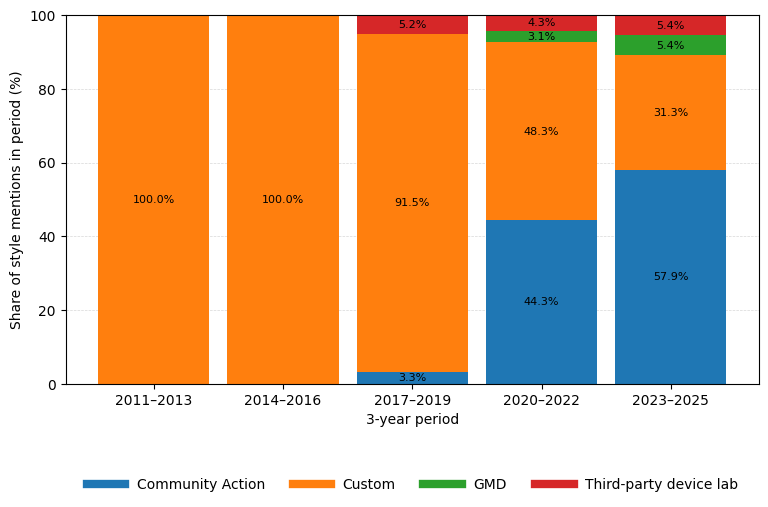

In [4]:
# === Observation 3.2 — Stacked Bar (3-year buckets, per-style union, removed-only rule) ===
# Slightly larger gaps between bars: width=0.86 and small x-margins.

from __future__ import annotations
from pathlib import Path
from datetime import datetime, timezone, timedelta
from typing import Dict, List, Optional, Tuple
import json
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# ---------- Paths ----------
WORK_ROOT_MINED = Path(r"C:\Android Mobile App\Step2_Clone_Repo\Type_1\Aug_10\RQ3")
OUTPUT_MINE = WORK_ROOT_MINED / "mineV9.3"

# ---------- Settings ----------
CUTOFF_ISO   = "2025-08-10 23:59:59 +0000"
PERSIST_DAYS = 14.0
STYLES = ("Emu_Community", "Emu_Custom", "GMD", "ThirdParty")
DISPLAY_MAP = {
    "Emu_Community": "Community Action",
    "Emu_Custom":    "Custom",
    "GMD":           "GMD",
    "ThirdParty":    "Third-party device lab",
}
DISPLAY_ORDER = [DISPLAY_MAP[s] for s in STYLES]
YEAR_START, YEAR_END, BUCKET_SIZE = 2008, 2025, 3

# ---------- Helpers ----------
def parse_iso(s: Optional[str]) -> Optional[datetime]:
    if not s: return None
    s = s.strip().replace("Z", "+00:00")
    if len(s) >= 5 and (s[-5] in ["+","-"]) and s[-3] != ":":
        s = s[:-2] + ":" + s[-2:]
    dt = datetime.fromisoformat(s)
    if dt.tzinfo is None: dt = dt.replace(tzinfo=timezone.utc)
    return dt.astimezone(timezone.utc)

def days_between(a: datetime, b: datetime) -> float:
    return (b - a).total_seconds() / 86400.0

def read_repo_jsons(out_dir: Path) -> List[Path]:
    return sorted([p for p in out_dir.glob("*.emulator_timeline.json") if p.name != "index_summary.json"])

def month_start_key(dt: datetime) -> pd.Timestamp:
    u = dt.astimezone(timezone.utc)
    return pd.Timestamp(u.year, u.month, 1)

def next_month(ts: pd.Timestamp) -> pd.Timestamp:
    y, m = ts.year, ts.month
    return pd.Timestamp(y + (1 if m == 12 else 0), 1 if m == 12 else m + 1, 1)

def month_range_covering(start: datetime, end: datetime) -> List[pd.Timestamp]:
    if end <= start: return []
    months, cur = [], month_start_key(start)
    last = month_start_key(end - timedelta(microseconds=1))
    while cur <= last:
        months.append(cur); cur = next_month(cur)
    return months

def bucket_label(year: int) -> str:
    k = (year - YEAR_START) // BUCKET_SIZE
    y0 = YEAR_START + k * BUCKET_SIZE
    y1 = min(y0 + BUCKET_SIZE - 1, YEAR_END)
    return f"{y0}–{y1}"

CUTOFF_DT = parse_iso(CUTOFF_ISO)

def build_episodes(timeline_rows: List[Dict], cutoff_dt: datetime) -> List[Dict]:
    rows = sorted((r for r in (timeline_rows or []) if r.get("styles")),
                  key=lambda r: parse_iso(r.get("date")) or datetime.min.replace(tzinfo=timezone.utc))
    eps = []
    for i, r in enumerate(rows):
        start = parse_iso(r.get("date"))
        nxt   = parse_iso(rows[i+1].get("date")) if i+1 < len(rows) else cutoff_dt
        if start is None: continue
        end = min(nxt or cutoff_dt, cutoff_dt)
        if end <= start: continue
        eps.append({"start": start, "end": end, "styles": set(r.get("styles") or [])})
    return eps

def merge_intervals(intervals: List[Tuple[datetime, datetime]]) -> List[Tuple[datetime, datetime]]:
    if not intervals: return []
    intervals.sort(key=lambda ab: ab[0]); merged = []; s, e = intervals[0]
    for a, b in intervals[1:]:
        if a <= e: e = max(e, b)
        else: merged.append((s, e)); s, e = a, b
    merged.append((s, e)); return merged

def per_style_intervals(episodes: List[Dict]) -> Dict[str, List[Tuple[datetime, datetime]]]:
    m = {s: [] for s in STYLES}
    for ep in episodes:
        for s in STYLES:
            if s in ep["styles"]: m[s].append((ep["start"], ep["end"]))
    return {s: merge_intervals(v) for s, v in m.items() if v}

def apply_removed_only_rule(psi: Dict[str, List[Tuple[datetime, datetime]]],
                            cutoff_dt: datetime, min_days: float) -> Dict[str, List[Tuple[datetime, datetime]]]:
    kept = {}
    for s, ivs in psi.items():
        out = [(a, b) for a, b in ivs if (days_between(a, b) >= min_days) or (b == cutoff_dt)]
        if out: kept[s] = out
    return kept

# ---------- Build monthly activity ----------
json_files = read_repo_jsons(OUTPUT_MINE)
rows = []
for jf in json_files:
    with jf.open("r", encoding="utf-8") as f:
        data = json.load(f)
    repo = data.get("repo_name") or jf.stem
    episodes = build_episodes(data.get("timeline") or [], CUTOFF_DT)
    kept = apply_removed_only_rule(per_style_intervals(episodes), CUTOFF_DT, PERSIST_DAYS)

    all_ints = [iv for ivs in kept.values() for iv in ivs]
    if not all_ints: continue
    months = month_range_covering(min(s for s, _ in all_ints), max(e for _, e in all_ints))
    for m in months:
        m_start, m_end = m.tz_localize("UTC"), next_month(m).tz_localize("UTC")
        row, any_style = {"repo_name": repo, "month": m}, False
        for sty in STYLES:
            active = any(a < m_end and b > m_start for a, b in kept.get(sty, []))
            row[sty] = 1 if active else 0
            any_style |= active
        if any_style: rows.append(row)

dfm = pd.DataFrame(rows).sort_values(["month","repo_name"]).reset_index(drop=True)
dfm["bucket"] = dfm["month"].dt.year.map(bucket_label)

style_bucket_counts = (
    dfm.groupby(["bucket","repo_name"])[list(STYLES)]
       .max()
       .reset_index()
       .groupby("bucket")[list(STYLES)]
       .sum()
       .sort_index()
)
tot_mentions = style_bucket_counts.sum(axis=1).replace(0, pd.NA)
style_bucket_shares = (style_bucket_counts.T / tot_mentions).T.fillna(0.0) * 100.0
style_bucket_shares = style_bucket_shares.rename(columns=DISPLAY_MAP)
style_bucket_shares = style_bucket_shares[[c for c in [DISPLAY_MAP[s] for s in STYLES] if c in style_bucket_shares.columns]]

# ---------- Plot (slightly larger gaps; bottom legend as colored lines) ----------
fig, ax = plt.subplots(figsize=(8, 5))
style_bucket_shares.plot(kind="bar", stacked=True, ax=ax, width=0.86, edgecolor="none")

#ax.set_title("Share of environment styles by 3-year period")
ax.set_xlabel("3-year period")
ax.set_ylabel("Share of style mentions in period (%)")
ax.set_ylim(0, 100)
ax.set_xticklabels(style_bucket_shares.index.tolist(), rotation=0, ha="center")
ax.margins(x=0.015, y=0)                   # small horizontal gap between bars
ax.grid(True, axis="y", linestyle="--", linewidth=0.5, alpha=0.5)
ax.set_axisbelow(True)

# Legend proxies with exact bar colors
bar_containers = [c for c in ax.containers if hasattr(c, "patches") and c.patches]
legend_labels = style_bucket_shares.columns.tolist()
colors = [bc.patches[0].get_facecolor() for bc in bar_containers[:len(legend_labels)]]
proxies = [Line2D([0], [0], color=c, lw=6) for c in colors]

leg = ax.get_legend()
if leg is not None: leg.remove()
ax.legend(proxies, legend_labels, loc="upper center", bbox_to_anchor=(0.5, -0.22),
          ncol=len(legend_labels), frameon=False, handlelength=2.8)

# On-bar percent labels
for i, bucket in enumerate(style_bucket_shares.index):
    cum = 0.0
    for sty in legend_labels:
        val = float(style_bucket_shares.loc[bucket, sty])
        if val <= 0.0: continue
        ax.text(i, cum + val/2.0, f"{val:.1f}%", ha="center", va="center", fontsize=8)
        cum += val

plt.subplots_adjust(bottom=.3)  # room for legend
plt.tight_layout()
plt.show()


## RQ3 - F3 - State Machine - Averge Dwelling for each period
## RQ3 - F4 - 1st and 2nd Transition from each style - State machine diagram

In [6]:
# -*- coding: utf-8 -*-
"""
RQ3 — Merged state view with 'Mixed' = any multi-style overlap (no 'Both') + transition matrices.

Policy:
- Build per-style stints from timeline episodes.
- Drop stints that END BEFORE CUTOFF and have duration < 14 days.
- Keep stints that are ACTIVE AT CUTOFF regardless of duration.

States:
- Single-style: 'Emu_Community', 'Emu_Custom', 'GMD', 'ThirdParty'
- Multi-style overlap (size >= 2): 'Mixed'
- Periods with no style are ignored.

Outputs (print-only):
- Processed repo count
- Retained per-style stints (post 14-day rule)
- Merged state dwell table (with 'Mixed')
- Top-2 next-state probabilities
- Transition matrix (counts) and row-normalized probabilities
"""

from __future__ import annotations
from pathlib import Path
from datetime import datetime, timezone
from typing import Dict, List, Optional, Tuple, Set
import json
import pandas as pd
from collections import defaultdict, Counter

# ----------------- Config -----------------
JSON_DIR    = Path(r"C:\Android Mobile App\Step2_Clone_Repo\Type_1\Aug_10\RQ3\mineV9.3")
CUTOFF_ISO  = "2025-08-10 23:59:59 +0000"
PERSIST_MIN = 14.0
STYLES      = ("Emu_Community", "Emu_Custom", "GMD", "ThirdParty")
STATE_ORDER = ["Emu_Community", "Emu_Custom", "GMD", "ThirdParty", "Mixed"]  # fixed order, no 'Both'

# -------------- Helpers -------------------
def parse_iso(s: Optional[str]) -> Optional[datetime]:
    if not s: return None
    s = s.strip()
    if s.endswith("Z"):
        s = s[:-1] + "+00:00"
    if len(s) >= 5 and (s[-5] in ["+","-"]) and s[-3] != ":":
        s = s[:-2] + ":" + s[-2:]
    try:
        dt = datetime.fromisoformat(s)
        if dt.tzinfo is None:
            dt = dt.replace(tzinfo=timezone.utc)
        return dt.astimezone(timezone.utc)
    except Exception:
        return None

def days_between(a: datetime, b: datetime) -> float:
    return (b - a).total_seconds() / 86400.0

CUTOFF_DT = parse_iso(CUTOFF_ISO)
assert CUTOFF_DT is not None, "Bad CUTOFF_ISO"

def read_repo_jsons(root: Path) -> List[Path]:
    return sorted([p for p in root.glob("*.emulator_timeline.json") if p.name != "index_summary.json"])

def build_episodes(timeline_rows: List[Dict], cutoff_dt: datetime) -> List[Dict]:
    """Contiguous episodes [start,end) from dated rows (styles may be empty), capped at cutoff."""
    rows = sorted(
        (r for r in (timeline_rows or []) if r.get("date") is not None),
        key=lambda r: parse_iso(r.get("date")) or datetime.min.replace(tzinfo=timezone.utc)
    )
    eps: List[Dict] = []
    for i, r in enumerate(rows):
        start = parse_iso(r.get("date"))
        if start is None:
            continue
        styles_raw = set(r.get("styles") or [])
        next_dt = parse_iso(rows[i+1].get("date")) if (i + 1) < len(rows) else cutoff_dt
        end = min(next_dt or cutoff_dt, cutoff_dt)
        if end < start:
            continue
        eps.append({"start": start, "end": end, "styles": styles_raw, "duration_days": max(0.0, days_between(start, end))})
    return eps

def merge_intervals(intervals: List[Tuple[datetime, datetime]]) -> List[Tuple[datetime, datetime]]:
    """Merge overlapping/contiguous [start,end) intervals."""
    if not intervals:
        return []
    intervals.sort(key=lambda ab: ab[0])
    out: List[Tuple[datetime, datetime]] = []
    cs, ce = intervals[0]
    for a, b in intervals[1:]:
        if a <= ce:
            if b > ce:
                ce = b
        else:
            out.append((cs, ce))
            cs, ce = a, b
    out.append((cs, ce))
    return out

def per_style_intervals_from_timeline(episodes: List[Dict]) -> Dict[str, List[Tuple[datetime, datetime]]]:
    """Collect and merge sub-intervals per style from timeline episodes."""
    m = {s: [] for s in STYLES}
    for ep in episodes:
        present = ep["styles"] or set()
        for s in STYLES:
            if s in present:
                m[s].append((ep["start"], ep["end"]))
    return {s: merge_intervals(v) for s, v in m.items() if v}

# ---------- Per-style stints with the 14-day rule ----------
def build_retained_per_style_stints(data: Dict) -> Dict[str, List[Tuple[datetime, datetime]]]:
    """
    Timeline-only per-style stints, then apply:
      - Drop stints that END BEFORE cutoff AND duration < PERSIST_MIN
      - Keep all active-at-cutoff stints (end == cutoff) regardless of duration
    """
    episodes = build_episodes(data.get("timeline") or [], CUTOFF_DT)
    psi = per_style_intervals_from_timeline(episodes)

    retained: Dict[str, List[Tuple[datetime, datetime]]] = {}
    for style, ivs in psi.items():
        kept: List[Tuple[datetime, datetime]] = []
        for a, b in ivs:
            dur = days_between(a, b)
            if (b < CUTOFF_DT) and (dur < PERSIST_MIN):
                continue  # drop short stint that ended before cutoff
            kept.append((a, b))
        if kept:
            retained[style] = kept
    return retained

# ---------- Merged state view with 'Mixed' for ANY overlap ----------
def build_state_segments_from_retained(per_style: Dict[str, List[Tuple[datetime, datetime]]]) -> List[Tuple[datetime, datetime, str]]:
    """
    Build merged state segments from retained per-style stints.
    - Single style -> that style
    - Any multi-style overlap (size >= 2) -> 'Mixed'
    """
    if not per_style:
        return []
    points: Set[datetime] = set()
    for ivs in per_style.values():
        for a, b in ivs:
            points.add(a); points.add(b)
    xs = sorted(points)
    segs: List[Tuple[datetime, datetime, str]] = []
    for i in range(len(xs) - 1):
        a, b = xs[i], xs[i+1]
        if b <= a:
            continue
        active: List[str] = []
        for st, ivs in per_style.items():
            # any overlap?
            for s, e in ivs:
                if s < b and e > a:
                    active.append(st)
                    break
        if not active:
            continue
        state = active[0] if len(active) == 1 else "Mixed"
        segs.append((a, b, state))
    # coalesce adjacent same-state segments
    merged: List[Tuple[datetime, datetime, str]] = []
    for a, b, st in segs:
        if not merged or st != merged[-1][2] or a != merged[-1][1]:
            merged.append((a, b, st))
        else:
            merged[-1] = (merged[-1][0], b, st)
    return merged

# ----------------- RUN -----------------
json_files = read_repo_jsons(JSON_DIR)
if not json_files:
    raise FileNotFoundError(f"No miner JSONs found in {JSON_DIR}")

repos_processed = 0
per_style_stints_retained = 0
state_durations: Dict[str, List[float]] = defaultdict(list)
transitions: Counter = Counter()

for jf in json_files:
    with jf.open("r", encoding="utf-8") as f:
        data = json.load(f)

    per_style = build_retained_per_style_stints(data)
    if not per_style:
        continue

    per_style_stints_retained += sum(len(v) for v in per_style.values())
    segs = build_state_segments_from_retained(per_style)
    if segs:
        for a, b, st in segs:
            d = days_between(a, b)
            if d > 0:
                state_durations[st].append(d)
        for i in range(len(segs) - 1):
            s = segs[i][2]; t = segs[i+1][2]
            if s != t:
                transitions[(s, t)] += 1

    repos_processed += 1

# ----------------- PRINT -----------------
print(f"\nProcessed repositories: {repos_processed}")
print(f"Retained per-style stints (post 14-day rule): {per_style_stints_retained}")

# Dwell table (fixed order, no 'Both')
rows = []
for st in STATE_ORDER:
    vals = state_durations.get(st, [])
    if not vals:
        continue
    avg = (sum(vals) / len(vals)) if vals else 0.0
    rows.append((st, round(avg, 2), len(vals)))
df_dwell = pd.DataFrame(rows, columns=["state", "avg_dwell_days", "num_segments"])
print("\nMerged state dwell (multi-style overlap = 'Mixed'):")
print(df_dwell.to_string(index=False))

# Top-2 next-state probabilities
print("\nTop-2 next-state probabilities (state view):")
by_src = defaultdict(Counter)
for (s, t), c in transitions.items():
    by_src[s][t] += c
any_transitions = False
for s in STATE_ORDER:
    if s not in by_src:
        continue
    any_transitions = True
    tot = sum(by_src[s].values())
    ranked = by_src[s].most_common(2)
    if tot == 0 or not ranked:
        print(f"  {s}: (no outgoing transitions)")
        continue
    parts = [f"{t} (p={c/tot:.3f}, n={c})" for t, c in ranked]
    print(f"  {s} → " + "; ".join(parts))
if not any_transitions:
    print("  (no transitions observed)")

# Transition matrices (counts and row-normalized) — fixed order
print("\nTransition matrix (counts):")
count_mat = []
for s in STATE_ORDER:
    row = []
    for t in STATE_ORDER:
        row.append(transitions.get((s, t), 0))
    count_mat.append(row)
df_counts = pd.DataFrame(count_mat, index=STATE_ORDER, columns=STATE_ORDER)
print(df_counts.to_string())

print("\nTransition matrix (row-normalized probabilities):")
prob_mat = []
for s in STATE_ORDER:
    total = sum(transitions.get((s, t), 0) for t in STATE_ORDER)
    row = []
    for t in STATE_ORDER:
        c = transitions.get((s, t), 0)
        row.append(round(c / total, 3) if total > 0 else 0.0)
    prob_mat.append(row)
df_probs = pd.DataFrame(prob_mat, index=STATE_ORDER, columns=STATE_ORDER)
print(df_probs.to_string())



Processed repositories: 350
Retained per-style stints (post 14-day rule): 456

Merged state dwell (multi-style overlap = 'Mixed'):
        state  avg_dwell_days  num_segments
Emu_Community         1121.40           229
   Emu_Custom         2302.31           176
          GMD          534.70            18
   ThirdParty         1266.34            20
        Mixed          586.61            20

Top-2 next-state probabilities (state view):
  Emu_Community → Mixed (p=0.471, n=8); GMD (p=0.235, n=4)
  Emu_Custom → Emu_Community (p=0.879, n=58); ThirdParty (p=0.076, n=5)
  GMD → Mixed (p=1.000, n=6)
  ThirdParty → Mixed (p=0.800, n=4); GMD (p=0.200, n=1)
  Mixed → Emu_Community (p=0.556, n=5); ThirdParty (p=0.222, n=2)

Transition matrix (counts):
               Emu_Community  Emu_Custom  GMD  ThirdParty  Mixed
Emu_Community              0           3    4           2      8
Emu_Custom                58           0    1           5      2
GMD                        0           0    0       

State Machine Diagram

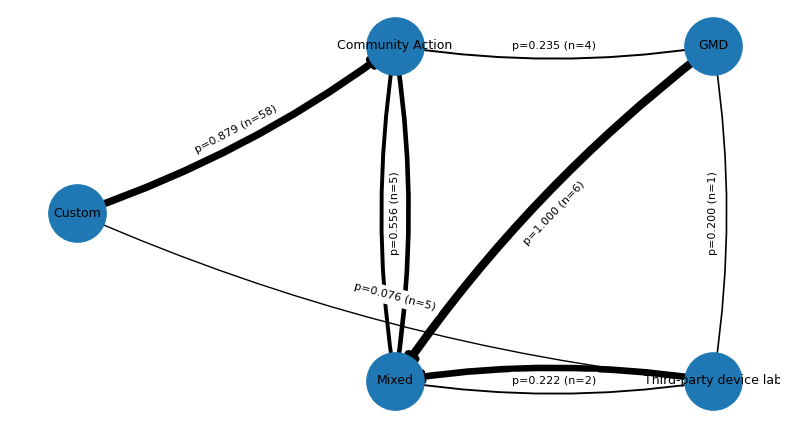

In [7]:
# -*- coding: utf-8 -*-
"""
State-machine transition diagram (top-1 and top-2 edges), including 'Mixed'.

This script draws a directed graph where:
- Nodes = styles
- Edges = top-1 and top-2 next-state transitions with probabilities (and optional counts)
- Edge widths scale with probability
- No special colors are set (matplotlib defaults)

You can edit the `TOP2` dict below to reflect your latest numbers.
"""

import math
import matplotlib.pyplot as plt

try:
    import networkx as nx
except ImportError:
    raise SystemExit("Please install networkx (e.g., pip install networkx) to run this script.")

# -----------------------------
# INPUT: Top-2 transitions
# (Use paper labels; include Mixed)
# -----------------------------
# Each entry: source: [(target, prob, count), ...]  (prob in [0,1])
TOP2 = {
    "Custom": [
        ("Community Action", 0.879, 58),
        ("Third-party device lab", 0.076, 5),
        # ("GMD", 0.015, 1),  # (third best; not plotted)
    ],
    "Community Action": [
        ("Mixed", 0.471, 8),
        ("GMD", 0.235, 4),
    ],
    "GMD": [
        ("Mixed", 1.000, 6),
    ],
    "Third-party device lab": [
        ("Mixed", 0.800, 4),
        ("GMD", 0.200, 1),
    ],
    "Mixed": [
        ("Community Action", 0.556, 5),
        ("Third-party device lab", 0.222, 2),
        # ("GMD", 0.222, 2),  # tie for #2; omit or swap if you prefer
    ],
}

# Optional: control which nodes appear (keeps layout stable)
NODES = ["Custom", "Community Action", "GMD", "Third-party device lab", "Mixed"]

# -----------------------------
# Build graph
# -----------------------------
G = nx.DiGraph()
G.add_nodes_from(NODES)

# Add edges (top-1 and top-2)
for src, edges in TOP2.items():
    for (tgt, p, n) in edges[:2]:  # ensure top-2 only
        if p <= 0 or src == tgt:
            continue
        # store probability & count in edge attributes
        G.add_edge(src, tgt, prob=float(p), count=int(n))

# -----------------------------
# Layout
# -----------------------------
# A fixed layout helps reproducibility in papers. Feel free to tweak positions.
pos = {
    "Custom": (0.0, 0.0),
    "Community Action": (1.5, 0.6),
    "Mixed": (1.5, -0.6),
    "GMD": (3.0, 0.6),
    "Third-party device lab": (3.0, -0.6),
}

# If any node missing in pos (e.g., you add/remove), fall back to spring_layout for all
if set(pos.keys()) != set(G.nodes):
    pos = nx.spring_layout(G, seed=7, k=1.0)

# -----------------------------
# Draw
# -----------------------------
plt.figure(figsize=(8, 4.5))  # adjust as needed

# Node styling (no explicit colors)
nx.draw_networkx_nodes(G, pos, node_size=1700, linewidths=1.0)
nx.draw_networkx_labels(G, pos, font_size=9)

# Edge widths scaled by probability
probs = [G[u][v]["prob"] for u, v in G.edges]
# simple width scaling (min width 1.0)
edge_widths = [max(1.0, 6.0 * p) for p in probs]

nx.draw_networkx_edges(
    G, pos,
    arrowstyle="->",
    arrowsize=15,
    width=edge_widths,
    connectionstyle="arc3,rad=0.08",  # slight curve to reduce overlap
)

# Edge labels: show p and (n)
edge_labels = {(u, v): f"p={G[u][v]['prob']:.3f} (n={G[u][v]['count']})" for u, v in G.edges}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=8, label_pos=0.5)

plt.axis("off")
#plt.title("RQ3 — State-machine (Top-1/Top-2 Transitions, incl. Mixed)")
plt.tight_layout()
plt.show()

# -----------------------------
# Optional: save to file
# -----------------------------
# plt.savefig("rq3_state_machine_top2.png", dpi=300, bbox_inches="tight")
